In [1]:
print("Hello")

Hello


In [ ]:
# =========================================
# SETUP WORKSHOP ENVIRONMENT
# =========================================

import os

!git clone https://github.com/agiannoul/XAISchool.git

print("Files in repository:")
print(os.listdir())

In [3]:
!pip install scikit-survival
!pip install cvxpy

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ------------------ --------------------- 0.5/1.1 MB 1.2 MB/s eta 0:00:01
   ------------------ --------------------- 0.5/1.1 MB 1.2 MB/s eta 0:00:01
   --------------------------- ------------ 0.8/1.1 MB 838.9 kB/s eta 0:00:01
   --------------------------- ------------ 0.8/1.1 MB 838.9 kB/s eta 0:00:01
   ------------------------------------ --- 1.0/1.1 MB 762.8 kB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 683.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/887.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/887.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/887.3 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/887.3 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/887.3 kB ? eta -:--:--
   ---------------------- -------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-survival 0.25.0 requires osqp<1.0.0,>=0.6.3, but you have osqp 1.1.1 which is incompatible.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, brier_score

from survlime_explainer import SurvLimeExplainer

## Dataset preperation

- load dataset
- label preperation
- spliting dataset

In [2]:
df = pd.read_csv("ttf_dataset.csv")
df.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Bearing_temperature,Power_factor,Air_flow_rate,TTF_hours,event
0,2020-02-01 01:10:00,7.293214,9.125088,4.805062,1.243276,8.813017,60.376461,0.223964,57.480492,0.082083,0.679854,665.645229,1
1,2020-02-01 01:20:00,7.337202,9.190147,5.085278,1.249185,8.844360,60.491504,0.220237,57.748497,0.085360,0.734879,665.477895,1
2,2020-02-01 01:30:00,7.369224,9.236271,5.314668,1.247425,8.918555,60.523896,0.218330,58.021112,0.087776,0.785735,665.310661,1
3,2020-02-01 01:40:00,7.226074,9.270082,5.440938,1.237028,8.920938,60.634622,0.175865,58.347425,0.088617,0.834552,665.143608,1
4,2020-02-01 01:50:00,7.398180,9.314863,5.547639,1.243310,8.886944,60.862910,0.194699,58.610860,0.087980,0.868197,664.976264,1


In [3]:
# keep chronoepilogi features
Selected_features=['TP2', 'DV_pressure', 'Oil_temperature', 'Power_factor']
LAG = 6

df=df[["timestamp"]+Selected_features+["TTF_hours","event"]]
df.head()

,timestamp,TP2,DV_pressure,Oil_temperature,Power_factor,TTF_hours,event
0,2020-02-01 01:10:00,7.293214,1.243276,60.376461,0.082083,665.645229,1
1,2020-02-01 01:20:00,7.337202,1.249185,60.491504,0.085360,665.477895,1
2,2020-02-01 01:30:00,7.369224,1.247425,60.523896,0.087776,665.310661,1
3,2020-02-01 01:40:00,7.226074,1.237028,60.634622,0.088617,665.143608,1
4,2020-02-01 01:50:00,7.398180,1.243310,60.862910,0.087980,664.976264,1


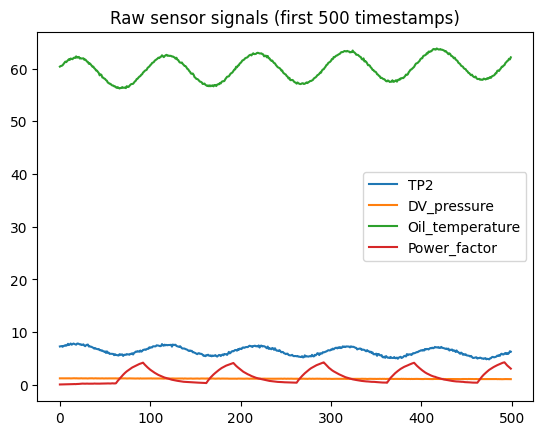

In [4]:
plt.figure()
for f in Selected_features:
    plt.plot(df[f].values[:500], label=f)
plt.legend()
plt.title("Raw sensor signals (first 500 timestamps)")
plt.show()

Create lag features

In [5]:
# =========================================
# 4. CREATE WINDOWED FEATURES (LAG=6)
# =========================================

def create_lag_features(df, features, lag=6):
    df_lag = df.copy()
    
    for f in features:
        for i in range(1, lag + 1):
            df_lag[f"{f}_lag{i}"] = df_lag[f].shift(i)
    
    df_lag = df_lag.dropna().reset_index(drop=True)
    return df_lag


df_lag = create_lag_features(df, Selected_features, LAG)
print("After lag transformation:", df_lag.shape)


After lag transformation: (25508, 31)


## Define X  and Y

- **X** refers to input/observations

- **Y** refers to the time-to-event labels we have. The labels are assemblied from the Time until next event **T** and an indicator if the **event**  is failure or censoring.

In [6]:
feature_cols = [c for c in df_lag.columns if c not in ["timestamp", "TTF_hours", "event"]]

X = df_lag[feature_cols]

# survival target

y = list(zip(df_lag["event"].astype(bool), df_lag["TTF_hours"]))

y_struct = Surv.from_arrays(
    event=df_lag["event"].astype(bool),
    time=df_lag["TTF_hours"]
)

print("Label tuples:")
print(y[0])
print(y[100])
print(y[-10])

Label tuples:
(True, 664.6413823666754)
(True, 647.9710986324401)
(False, 1.4943159811669875)


## Spliting Data

We will split the data based on time (time-aware spliting) 

- **Train** data are used to train the Survival Model

- **Test** data will be used to test our model and osberve its capabilities. Then we will use observations from Test data to explain.

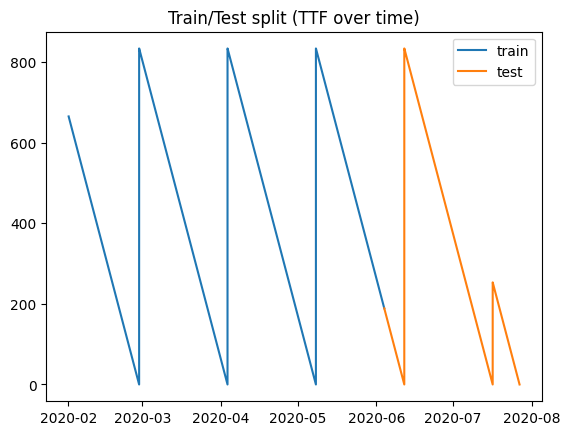

In [7]:
df_lag['timestamp']=pd.to_datetime(df_lag['timestamp'])
df_lag = df_lag.sort_values("timestamp").reset_index(drop=True)
split_idx = int(len(df_lag) * 0.70)

train_df = df_lag.iloc[:split_idx]
test_df = df_lag.iloc[split_idx:]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = Surv.from_arrays(train_df["event"].astype(bool), train_df["TTF_hours"])
y_test = Surv.from_arrays(test_df["event"].astype(bool), test_df["TTF_hours"])

y_train_list = list(zip(train_df["event"].astype(bool), train_df["TTF_hours"]))
y_test_list = list(zip(test_df["event"].astype(bool), test_df["TTF_hours"]))

# VISUALIZATION 5: train/test split over time
plt.figure()
plt.plot(train_df["timestamp"],train_df["TTF_hours"].values, label="train")
plt.plot(test_df["timestamp"],test_df["TTF_hours"].values, label="test")
plt.legend()
plt.title("Train/Test split (TTF over time)")
plt.show()

## Train Survival Analysis model

We will use Gradient Boosting Survival Analysis as the Survival Analysis model using `sksurv` library (import: `from sksurv.ensemble import GradientBoostingSurvivalAnalysis`).

In [8]:
gbs = GradientBoostingSurvivalAnalysis(
    learning_rate=0.1, 
    n_estimators=30,
    random_state=42
)

In [9]:
gbs.fit(X_train, y_train)

,loss,'coxph'
,learning_rate,0.1
,n_estimators,30
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,random_state,42


# Evaluate the model

For the puprpose of the workshop we will use two metrics

- Brier-score: which test both discriminative ability and how well calibrated are the survival probabilities

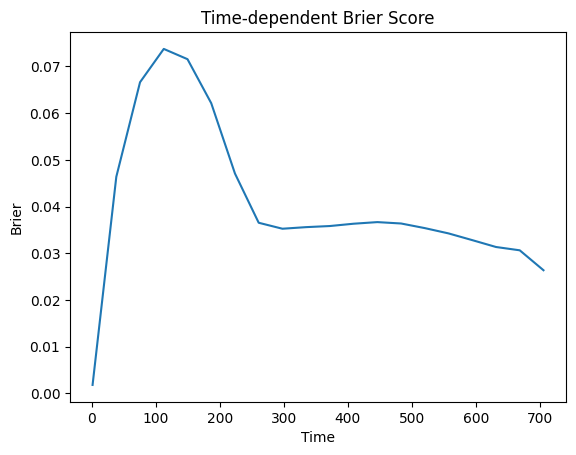

In [ ]:

# Brier score
max_time = np.percentile(y_test["time"], 90)
times = np.linspace(1, max_time, 20)

# build survival matrix: shape (n_samples, n_times)
surv_matrix = np.array([
    gbs.predict_survival_function(X_test.iloc[i:i+1])[0](times)
    for i in range(len(X_test))
])

bs = brier_score(y_train, y_test, surv_matrix, times)

plt.figure()
plt.plot(times, bs[1])
plt.title("Time-dependent Brier Score")
plt.xlabel("Time")
plt.ylabel("Brier")
ply.ylim([0,0.25])
plt.show()

### Example of a prediction

c:\Users\apost\.conda\envs\survival\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingSurvivalAnalysis was fitted with feature names
  warnings.warn(
c:\Users\apost\.conda\envs\survival\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingSurvivalAnalysis was fitted with feature names
  warnings.warn(


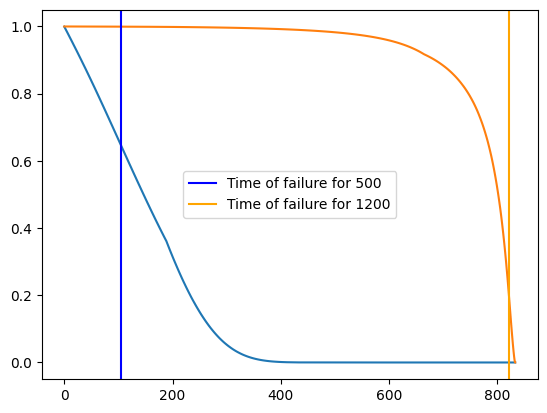

In [11]:
idx = 500
x1 = X_test.iloc[idx]
actual_time=y_test[idx][1]
surv_fn = gbs.predict_survival_function([x1])[0]
event_times_=surv_fn.x
idx2 = 1200
x2 = X_test.iloc[idx2]
actual_time2=y_test[idx2][1]
surv_fn2 = gbs.predict_survival_function([x2])[0]

plt.plot(surv_fn.x,surv_fn.y)
plt.plot(surv_fn2.x,surv_fn2.y)
plt.axvline(actual_time,color="blue",label=f"Time of failure for {idx}")
plt.axvline(actual_time2,color="orange",label=f"Time of failure for {idx2}")
plt.legend()
plt.show()

# EXPLANATION Survival model predictions using LIME

c:\Users\apost\.conda\envs\survival\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingSurvivalAnalysis was fitted with feature names
  warnings.warn(


[-0.03735855  0.03554598  0.00378304  0.08966394 -0.00816385 -0.0187609
 -0.02280847 -0.0090612  -0.05220675  0.02925156 -0.48480601  0.06715886
 -0.03279431 -0.54220772 -0.21646052 -0.26333812  0.00274978  0.00553291
  0.00367466  0.0032383   0.00384401  0.0042637  -0.0865482   0.01974511
 -0.02567829  0.03314624 -0.03853746  0.02108856]


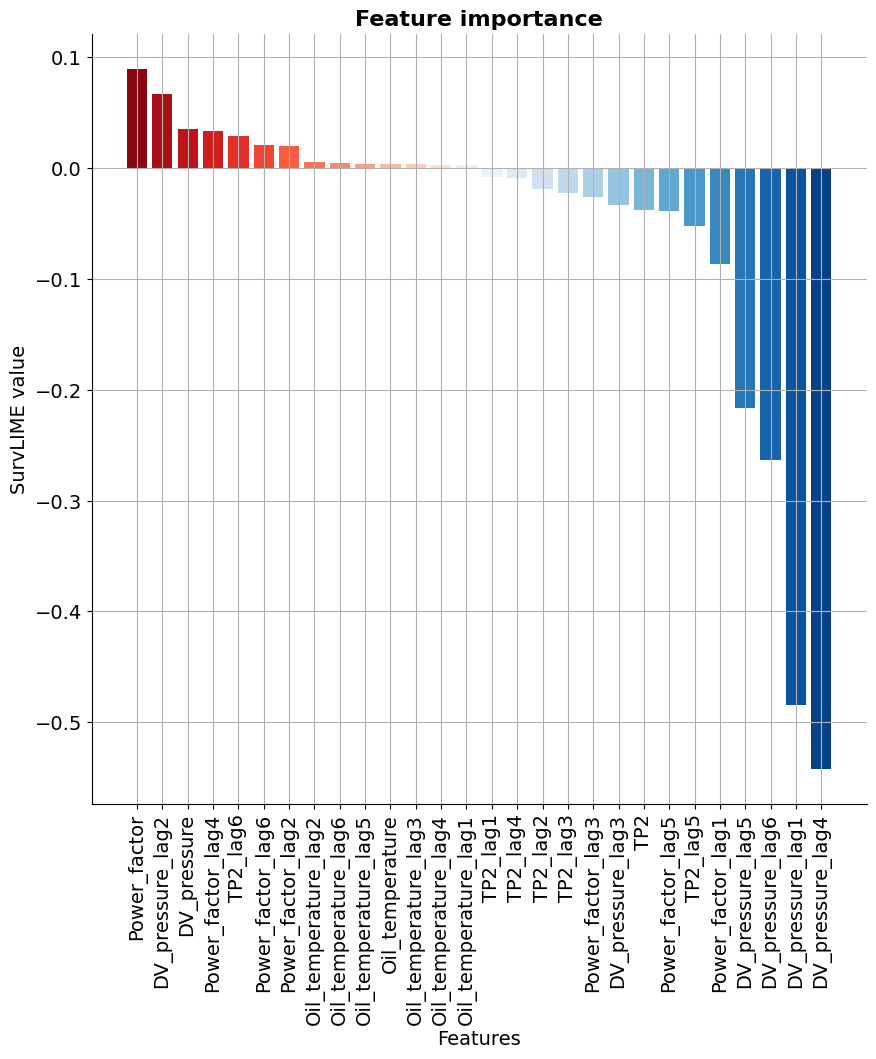

In [12]:
explainer_rsf = SurvLimeExplainer(
    training_features=X_train,
    training_events=[tp[0] for tp in y_train_list],
    training_times=[tp[1] for tp in y_train_list],
    model_output_times=event_times_,
    random_state=10,
)

idx = 500
x1 = X_test.iloc[idx]
actual_time = y_test["time"][idx]
surv_fn = gbs.predict_survival_function([x1])[0]

b_rsf = explainer_rsf.explain_instance(
    data_row=x1,
    predict_fn=gbs.predict_survival_function,
    num_samples=20,
    verbose=False,
)
print(b_rsf)

explainer_rsf.plot_weights()

In [ ]:
idx2 = 1200
x2 = X_test.iloc[idx2]
surv_fn = gbs.predict_survival_function([x2])[0]

b_rsf = explainer_rsf.explain_instance(
    data_row=x2,
    predict_fn=gbs.predict_survival_function,
    num_samples=40,
    verbose=False,
)

explainer_rsf.plot_weights()